In [1]:
import os
os.environ["ARCH_DISABLE_NUMBA"] = "1"

import pandas as pd
import yfinance as yfin
import datetime as dt
import numpy as np
import arch
import matplotlib.pyplot as plt

In [2]:
Ticker = ['^NSEI']

# Indicate the start and end dates
start = dt.datetime.now().replace(year=dt.datetime.now().year - 7)
end = dt.datetime.now()

nifty = yfin.download(Ticker, start = start, end = end)
print(nifty)

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2019-08-23  10829.349609  10862.549805  10637.150391  10699.599609  667100
2019-08-26  11057.849609  11070.299805  10756.549805  11000.299805  684100
2019-08-27  11105.349609  11141.750000  11049.500000  11106.549805  685600
2019-08-28  11046.099609  11129.650391  10987.650391  11101.299805  550000
2019-08-29  10948.299805  11021.099609  10922.400391  10996.049805  649900
...                  ...           ...           ...           ...     ...
2026-08-17  24287.650391  24360.099609  24226.949219  24343.449219  225400
2026-08-18  24154.900391  24269.650391  24154.900391  24223.849609  227000
2026-08-19  24078.300781  24172.849609  24025.650391  24152.050781  238700
2026-08-20  24231.849609  24265.150391  24184.550781  24225.449219  253900
2026-08-21  24252.000000 

In [3]:
dailyReturns = nifty['Close'].pct_change(1) * 100
dailyReturns = dailyReturns.dropna()

logReturns = np.log(nifty['Close']).diff()
logReturns = logReturns.dropna()

logReturns

Ticker,^NSEI
Date,
2019-08-26,0.020881
2019-08-27,0.004286
2019-08-28,-0.005350
2019-08-29,-0.008893
2019-08-30,0.006823
...,...
2026-08-17,-0.003221
2026-08-18,-0.005481
2026-08-19,-0.003176


In [4]:
logReturns['Returns'] = logReturns['^NSEI'] * 100

In [5]:
returns = logReturns['Returns']

In [6]:
model = arch.arch_model(returns, vol = 'Garch', p = 1, q = 1)
res = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 37513384433.5107
Iteration:      2,   Func. Count:     15,   Neg. LLF: 1285117057.0488725
Iteration:      3,   Func. Count:     23,   Neg. LLF: 3007.7240521112217
Iteration:      4,   Func. Count:     30,   Neg. LLF: 2281.595817535773
Iteration:      5,   Func. Count:     36,   Neg. LLF: 4115.34486829647
Iteration:      6,   Func. Count:     42,   Neg. LLF: 2276.4545820272056
Iteration:      7,   Func. Count:     47,   Neg. LLF: 2276.453026613815
Iteration:      8,   Func. Count:     52,   Neg. LLF: 2276.4529442160183
Iteration:      9,   Func. Count:     57,   Neg. LLF: 2276.4529411966014
Iteration:     10,   Func. Count:     61,   Neg. LLF: 2276.452941195981
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2276.4529411966014
            Iterations: 10
            Function evaluations: 61
            Gradient evaluations: 10


In [7]:
print(res.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2276.45
Distribution:                  Normal   AIC:                           4560.91
Method:            Maximum Likelihood   BIC:                           4582.72
                                        No. Observations:                 1727
Date:                Sun, Aug 23 2026   Df Residuals:                     1726
Time:                        18:08:54   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0656  2.167e-02      3.029  2.456e-03 [2.316e-0

In [8]:
res.conditional_volatility

garchVol = res.conditional_volatility

In [9]:
rolling_vol = returns.rolling(window=30).std()
rolling_vol

Date
2019-08-26         NaN
2019-08-27         NaN
2019-08-28         NaN
2019-08-29         NaN
2019-08-30         NaN
                ...   
2026-08-17    0.702394
2026-08-18    0.708781
2026-08-19    0.590155
2026-08-20    0.598017
2026-08-21    0.569065
Name: Returns, Length: 1727, dtype: float64

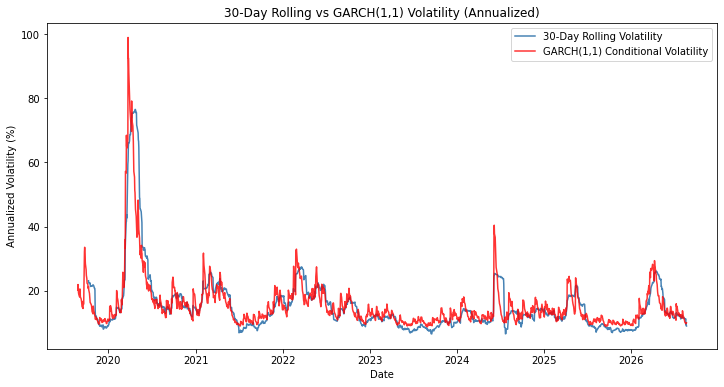

In [10]:
ann = np.sqrt(252)  # trading days per year, to annualize daily volatility

plt.figure(figsize=(12, 6))
plt.plot(rolling_vol * ann, label='30-Day Rolling Volatility', color='steelblue')
plt.plot(pd.Series(garchVol, index=returns.index) * ann,
         label='GARCH(1,1) Conditional Volatility', color='red', alpha=0.8)
plt.title('30-Day Rolling vs GARCH(1,1) Volatility (Annualized)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.show()

### Returns are fat-tailed — refit with a Student's-t innovation

The Normal GARCH above assumes Gaussian shocks, but Nifty returns have heavy tails (the excess kurtosis was clear in the earlier notebooks). A Student's-t innovation fits the tails better and, crucially, stops us from *understating* tail risk. The estimated degrees-of-freedom parameter `nu` is itself a fat-tail diagnostic — a smaller `nu` means heavier tails.

In [11]:
model_t = arch.arch_model(returns, vol='Garch', p=1, q=1, dist='StudentsT')
res_t = model_t.fit(disp='off')
print(res_t.summary())
print(f"\nNormal AIC: {res.aic:.1f}    Student-t AIC: {res_t.aic:.1f}")
print(f"Estimated degrees of freedom (nu): {res_t.params['nu']:.2f}")

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                      Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2225.82
Distribution:      Standardized Student's t   AIC:                           4461.63
Method:                  Maximum Likelihood   BIC:                           4488.90
                                              No. Observations:                 1727
Date:                      Sun, Aug 23 2026   Df Residuals:                     1726
Time:                              18:08:55   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

### Out-of-sample volatility forecast

Where GARCH earns its keep: forecasting the next few days' volatility. We forecast the conditional variance 5 trading days ahead and convert it to daily (and annualized) volatility.

In [12]:
forecast = res_t.forecast(horizon=5, reindex=False)
daily_vol = np.sqrt(forecast.variance.iloc[-1])
print("5-day-ahead volatility forecast:")
for i, v in enumerate(daily_vol, 1):
    print(f"  t+{i}:  daily vol = {v:.3f}%   (annualized ≈ {v * np.sqrt(252):.1f}%)")

5-day-ahead volatility forecast:
  t+1:  daily vol = 0.639%   (annualized ≈ 10.2%)
  t+2:  daily vol = 0.654%   (annualized ≈ 10.4%)
  t+3:  daily vol = 0.667%   (annualized ≈ 10.6%)
  t+4:  daily vol = 0.680%   (annualized ≈ 10.8%)
  t+5:  daily vol = 0.692%   (annualized ≈ 11.0%)


### Did the model remove the volatility clustering?

If GARCH(1,1) captured the conditional heteroskedasticity, the **standardized residuals** should have no ARCH effect left. We test with the ARCH-LM test (Engle): a *high* p-value means no remaining clustering, i.e. the model is adequate.

In [13]:
from statsmodels.stats.diagnostic import het_arch

std_resid = (res_t.resid / res_t.conditional_volatility).dropna()
lm_stat, lm_p, f_stat, f_p = het_arch(std_resid, nlags=10)
print(f"ARCH-LM test on standardized residuals (10 lags):")
print(f"  LM statistic = {lm_stat:.2f},  p-value = {lm_p:.3f}")
print("  -> p > 0.05: no ARCH effect remains, GARCH(1,1) is adequate."
      if lm_p > 0.05 else
      "  -> p < 0.05: clustering remains, consider a higher order or a different vol model.")

ARCH-LM test on standardized residuals (10 lags):
  LM statistic = 14.00,  p-value = 0.173
  -> p > 0.05: no ARCH effect remains, GARCH(1,1) is adequate.
